In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
def bitmask_summary(mask_values, names, bits):
    mask_values = np.array(mask_values, dtype=np.uint64)
    t = Table()
    t['name'] = np.concatenate([['None'], names])
    t['bit'] = np.concatenate([[-1], bits])
    t['count'] = 0
    t['count'][0] = np.sum(mask_values==0)
    for index in range(len(bits)):
        bit = bits[index]
        t['count'][index+1] = np.sum(mask_values & (2**bit)>0)
    t['frac (%)'] = t['count']/len(mask_values)*100
    t['frac (%)'].format = "%.2f"
    return t

--------

In [4]:
min_nobs = 1

In [6]:
randoms_columns = ['RA', 'DEC', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'MASKBITS', 'PHOTSYS', 'WISEMASK_W1']
randoms = Table(fitsio.read('/global/cfs/cdirs/desi/target/catalogs/dr9/0.49.0/randoms/resolve/randoms-1-0.fits', columns=randoms_columns))

In [7]:
mask = (randoms['NOBS_G']>=min_nobs) & (randoms['NOBS_R']>=min_nobs) & (randoms['NOBS_Z']>=min_nobs)
randoms = randoms[mask]

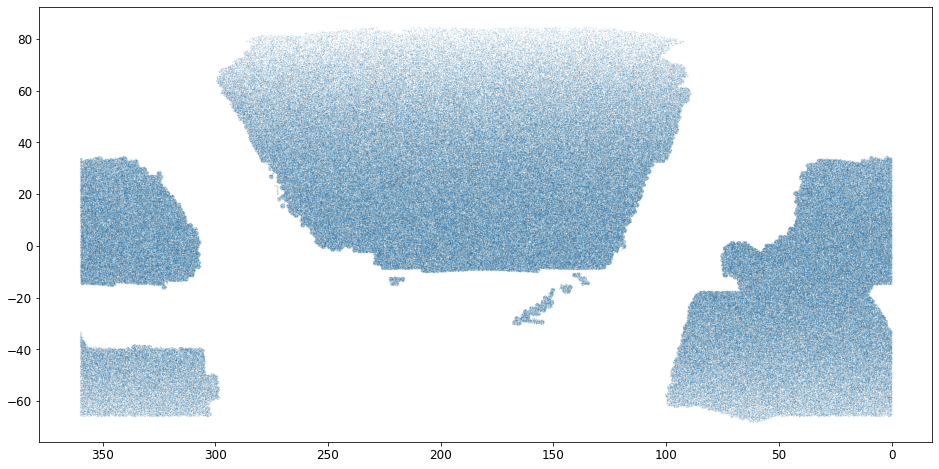

In [8]:
idx = np.random.choice(len(randoms), size=len(randoms)//50)

plt.figure(figsize=(16, 8))
plt.plot(randoms['RA'][idx], randoms['DEC'][idx], '.', ms=0.1, alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [9]:
bitnames = ['NPRIMARY', 'BRIGHT', 'SATUR_G', 'SATUR_R', 'SATUR_Z', 'ALLMASK_G', 'ALLMASK_R', 'ALLMASK_Z', 'WISEM1', 'WISEM2', 'BAILOUT', 'MEDIUM', 'GALAXY', 'CLUSTER']
bits = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

t = bitmask_summary(randoms['MASKBITS'], bitnames, bits)
print('\nRandoms:\n', t)


Randoms:
    name   bit  count   frac (%)
--------- --- -------- --------
     None  -1 45679926    92.65
 NPRIMARY   0    12799     0.03
   BRIGHT   1   407162     0.83
  SATUR_G   2    40906     0.08
  SATUR_R   3    77248     0.16
  SATUR_Z   4   151380     0.31
ALLMASK_G   5        0     0.00
ALLMASK_R   6        0     0.00
ALLMASK_Z   7        0     0.00
   WISEM1   8  1527422     3.10
   WISEM2   9   775174     1.57
  BAILOUT  10        0     0.00
   MEDIUM  11  2534790     5.14
   GALAXY  12    94957     0.19
  CLUSTER  13     6570     0.01


In [10]:
maskbits = [1, 12, 13]
mask_clean = np.ones(len(randoms), dtype=bool)
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}% masked fraction by {}'.format(np.sum(~mask_clean)/len(mask_clean)*100, maskbits))

maskbits = [1, 11, 12, 13]
mask_clean = np.ones(len(randoms), dtype=bool)
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}% masked fraction by {}'.format(np.sum(~mask_clean)/len(mask_clean)*100, maskbits))

maskbits = [1, 8, 9, 12, 13]
mask_clean = np.ones(len(randoms), dtype=bool)
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}% masked fraction by {}'.format(np.sum(~mask_clean)/len(mask_clean)*100, maskbits))

maskbits = [1, 8, 9, 11, 12, 13]
mask_clean = np.ones(len(randoms), dtype=bool)
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}% masked fraction by {}'.format(np.sum(~mask_clean)/len(mask_clean)*100, maskbits))

1.03% masked fraction by [1, 12, 13]
5.34% masked fraction by [1, 11, 12, 13]
3.69% masked fraction by [1, 8, 9, 12, 13]
7.07% masked fraction by [1, 8, 9, 11, 12, 13]


In [12]:
bitnames = ['BRIGHT', 'SPIKE', 'GHOST', 'LATENT', 'LATENT2', 'HALO', 'SATUR', 'SPIKE2']
bits = [0, 1, 2, 3, 4, 5, 6, 7]

t = bitmask_summary(randoms['WISEMASK_W1'], bitnames, bits)
print('\nRandoms:\n', t)


Randoms:
   name  bit  count   frac (%)
------- --- -------- --------
   None  -1 47774809    96.90
 BRIGHT   0   306284     0.62
  SPIKE   1   437709     0.89
  GHOST   2     2541     0.01
 LATENT   3    37738     0.08
LATENT2   4    11824     0.02
   HALO   5   962998     1.95
  SATUR   6     1186     0.00
 SPIKE2   7   304717     0.62


--------

In [16]:
min_nobs = 2

In [17]:
randoms_columns = ['RA', 'DEC', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'MASKBITS', 'PHOTSYS', 'WISEMASK_W1']
randoms = Table(fitsio.read('/global/cfs/cdirs/desi/target/catalogs/dr9/0.49.0/randoms/resolve/randoms-1-0.fits', columns=randoms_columns))

In [18]:
mask = (randoms['NOBS_G']>=min_nobs) & (randoms['NOBS_R']>=min_nobs) & (randoms['NOBS_Z']>=min_nobs)
randoms = randoms[mask]

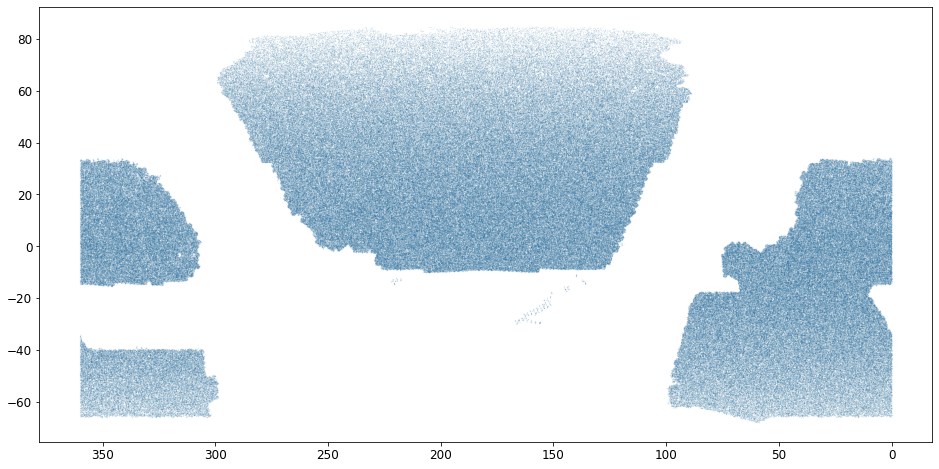

In [19]:
idx = np.random.choice(len(randoms), size=len(randoms)//50)

plt.figure(figsize=(16, 8))
plt.plot(randoms['RA'][idx], randoms['DEC'][idx], '.', ms=0.1, alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [20]:
bitnames = ['NPRIMARY', 'BRIGHT', 'SATUR_G', 'SATUR_R', 'SATUR_Z', 'ALLMASK_G', 'ALLMASK_R', 'ALLMASK_Z', 'WISEM1', 'WISEM2', 'BAILOUT', 'MEDIUM', 'GALAXY', 'CLUSTER']
bits = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

t = bitmask_summary(randoms['MASKBITS'], bitnames, bits)
print('\nRandoms:\n', t)


Randoms:
    name   bit  count   frac (%)
--------- --- -------- --------
     None  -1 43709469    92.94
 NPRIMARY   0    12224     0.03
   BRIGHT   1   359488     0.76
  SATUR_G   2    21645     0.05
  SATUR_R   3    48330     0.10
  SATUR_Z   4   119671     0.25
ALLMASK_G   5        0     0.00
ALLMASK_R   6        0     0.00
ALLMASK_Z   7        0     0.00
   WISEM1   8  1407792     2.99
   WISEM2   9   705339     1.50
  BAILOUT  10        0     0.00
   MEDIUM  11  2306819     4.90
   GALAXY  12    90800     0.19
  CLUSTER  13     5835     0.01


In [21]:
maskbits = [1, 12, 13]
mask_clean = np.ones(len(randoms), dtype=bool)
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}% masked fraction by {}'.format(np.sum(~mask_clean)/len(mask_clean)*100, maskbits))

maskbits = [1, 11, 12, 13]
mask_clean = np.ones(len(randoms), dtype=bool)
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}% masked fraction by {}'.format(np.sum(~mask_clean)/len(mask_clean)*100, maskbits))

maskbits = [1, 8, 9, 12, 13]
mask_clean = np.ones(len(randoms), dtype=bool)
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}% masked fraction by {}'.format(np.sum(~mask_clean)/len(mask_clean)*100, maskbits))

maskbits = [1, 8, 9, 11, 12, 13]
mask_clean = np.ones(len(randoms), dtype=bool)
for bit in maskbits:
    mask_clean &= (randoms['MASKBITS'] & 2**bit)==0
print('{:.2f}% masked fraction by {}'.format(np.sum(~mask_clean)/len(mask_clean)*100, maskbits))

0.97% masked fraction by [1, 12, 13]
5.10% masked fraction by [1, 11, 12, 13]
3.56% masked fraction by [1, 8, 9, 12, 13]
6.81% masked fraction by [1, 8, 9, 11, 12, 13]


In [22]:
bitnames = ['BRIGHT', 'SPIKE', 'GHOST', 'LATENT', 'LATENT2', 'HALO', 'SATUR', 'SPIKE2']
bits = [0, 1, 2, 3, 4, 5, 6, 7]

t = bitmask_summary(randoms['WISEMASK_W1'], bitnames, bits)
print('\nRandoms:\n', t)


Randoms:
   name  bit  count   frac (%)
------- --- -------- --------
   None  -1 45622913    97.01
 BRIGHT   0   271841     0.58
  SPIKE   1   402721     0.86
  GHOST   2     2279     0.00
 LATENT   3    35477     0.08
LATENT2   4    11170     0.02
   HALO   5   883099     1.88
  SATUR   6      927     0.00
 SPIKE2   7   282355     0.60
